El siguiente codigo tiene como objetivo hacer una carga inicial de los datos del csv para irlos procesando en el transcurso del análisis

In [ ]:
# ==========================================
# CELDA 1: CARGA Y PREPARACIÓN DE DATOS
# ==========================================

import pandas as pd
import numpy as np
import jinja2
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import skew, kurtosis
import os
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats

# Ruta del archivo
CSV_PATH = "regular_season_totals_2010_2024.csv"

# Cargar dataset
df = pd.read_csv(CSV_PATH)

# Información básica
print("=== INFORMACIÓN GENERAL DEL DATASET ===")
print(f"Registros: {df.shape[0]}")
print(f"Variables: {df.shape[1]}")
print("\nPrimeras filas:")
display(df.head())

# Conversión explícita de tipos si fuera necesario
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

print("\nCarga completada correctamente.")


=== INFORMACIÓN GENERAL DEL DATASET ===
Registros: 33316
Variables: 57

Primeras filas:


,SEASON_YEAR,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,AVAILABLE_FLAG
0,2022-23,1610612744,GSW,Golden State Warriors,22201230,2023-04-09T00:00:00,GSW @ POR,W,48.0,58,...,1,1578,55,512,457,678,2455,3,1,1.0
1,2020-21,1610612749,MIL,Milwaukee Bucks,22000051,2020-12-29T00:00:00,MIL @ MIA,W,48.0,51,...,146,1636,33,1830,1361,1552,1220,14,7,1.0
2,2013-14,1610612751,BKN,Brooklyn Nets,21300359,2013-12-16T00:00:00,BKN vs. PHI,W,48.0,47,...,22,2280,406,1979,1,1004,453,19,12,1.0
3,2013-14,1610612757,POR,Portland Trail Blazers,21300347,2013-12-14T00:00:00,POR @ PHI,W,48.0,52,...,2,2065,628,204,1269,272,2190,4,15,1.0
4,2018-19,1610612745,HOU,Houston Rockets,21801200,2019-04-07T00:00:00,HOU vs. PHX,W,48.0,53,...,84,176,149,917,1,244,1725,4,20,1.0



Carga completada correctamente.


EL siguiente codigo va a realizar el análisis descriptivo de las columnas del csv que se van a utilizar

In [3]:


# ==========================================
# FUNCIÓN DE ESTADÍSTICOS DESCRIPTIVOS
# ==========================================

def estadisticos_descriptivos(
    data: pd.DataFrame,
    variables: list,
    export_tex: bool = False,
    tex_filename: str = "estadisticos_descriptivos.tex"
):
    """
    Calcula estadísticos descriptivos y opcionalmente exporta a LaTeX.

    Parámetros
    ----------
    data : pd.DataFrame
        Dataset completo.
    variables : list
        Lista de variables a analizar.
    export_tex : bool
        Si True, exporta tabla en formato .tex.
    tex_filename : str
        Nombre del archivo LaTeX.
    """

    stats = pd.DataFrame(index=[
        "Media",
        "Mediana",
        "Moda",
        "Desv. Estándar",
        "Varianza",
        "Coef. Variación",
        "Mínimo",
        "Máximo",
        "Rango",
        "Q1",
        "Q3",
        "IQR"
    ])

    for var in variables:
        serie = data[var].dropna()

        stats.loc["Media", var] = serie.mean()
        stats.loc["Mediana", var] = serie.median()
        stats.loc["Moda", var] = serie.mode().iloc[0]
        stats.loc["Desv. Estándar", var] = serie.std()
        stats.loc["Varianza", var] = serie.var()
        stats.loc["Coef. Variación", var] = serie.std() / serie.mean() * 100
        stats.loc["Mínimo", var] = serie.min()
        stats.loc["Máximo", var] = serie.max()
        stats.loc["Rango", var] = serie.max() - serie.min()
        stats.loc["Q1", var] = serie.quantile(0.25)
        stats.loc["Q3", var] = serie.quantile(0.75)
        stats.loc["IQR", var] = stats.loc["Q3", var] - stats.loc["Q1", var]

    stats = stats.astype(float).round(3)

    # Mostrar resultados
    print("\n=== ESTADÍSTICOS DESCRIPTIVOS ===\n")
    display(stats)

    # Exportar a LaTeX si se solicita
    if export_tex:
        latex_table = stats.to_latex(
            column_format="|l|" + "c|" * len(variables),
            bold_rows=True,
            caption="Estadísticos descriptivos principales",
            label="tab:estadisticos_descriptivos",
            escape=False
        )

        with open(tex_filename, "w", encoding="utf-8") as f:
            f.write(r"\begin{table}[H]" + "\n")
            f.write(r"\centering" + "\n")
            f.write(r"\small" + "\n")
            f.write(latex_table + "\n")
            f.write(r"\end{table}" + "\n")

        print(f"✔ Archivo LaTeX generado: {tex_filename}")

    return stats

In [7]:
# ==========================================
# EJECUCIÓN DEL ANÁLISIS DESCRIPTIVO
# ==========================================

variables_analisis = ["PTS", "REB", "AST", "FG_PCT", "PLUS_MINUS"]

estadisticos = estadisticos_descriptivos(
    data=df,
    variables=variables_analisis,
    export_tex=True   # Cambia a False si no quieres el .tex
)



=== ESTADÍSTICOS DESCRIPTIVOS ===



C:\Users\marti\AppData\Local\Temp\ipykernel_5108\341349571.py:49: RuntimeWarning: divide by zero encountered in scalar divide
  stats.loc["Coef. Variación", var] = serie.std() / serie.mean() * 100


,PTS,REB,AST,FG_PCT,PLUS_MINUS
Media,106.040,43.444,23.384,0.460,0.000
Mediana,106.000,43.000,23.000,0.459,0.000
Moda,104.000,43.000,24.000,0.500,-7.000
Desv. Estándar,13.587,6.599,5.267,0.056,14.171
Varianza,184.599,43.552,27.740,0.003,200.816
Coef. Variación,12.813,15.191,22.523,12.071,inf
Mínimo,56.000,17.000,4.000,0.246,-73.000
Máximo,176.000,81.000,50.000,0.687,73.000
Rango,120.000,64.000,46.000,0.441,146.000
Q1,97.000,39.000,20.000,0.422,-9.000


✔ Archivo LaTeX generado: estadisticos_descriptivos.tex


Genera la tabla de distribución de la variable WL (Win/Loss).  para ver como estan distribuidos los datos de los partidos ganados y perdidos

In [8]:
# ==========================================
# DISTRIBUCIÓN DE RESULTADOS (WL)
# ==========================================

def tabla_wl(data, export_tex=False, tex_filename="distribucion_WL.tex"):
    """
    Genera la tabla de distribución de la variable WL (Win/Loss).
    Opcionalmente exporta la tabla a formato LaTeX.
    """

    # Conteo de resultados
    conteo = data["WL"].value_counts().sort_index()
    total = conteo.sum()

    # DataFrame final
    tabla = pd.DataFrame({
        "Resultado": conteo.index.map({"W": "Victoria (W)", "L": "Derrota (L)"}),
        "Frecuencia": conteo.values,
        "Porcentaje": (conteo.values / total * 100).round(2)
    })

    # Mostrar en consola
    print("\nDistribución de Resultados (WL):")
    print(tabla.to_string(index=False))

    # Exportar a LaTeX si se solicita
    if export_tex:
        latex_table = tabla.to_latex(
            index=False,
            column_format="|c|c|c|",
            caption="Distribución de resultados de partidos",
            label="tab:distribucion_wl",
            escape=False
        )

        with open(tex_filename, "w", encoding="utf-8") as f:
            f.write(r"\begin{table}[H]" + "\n")
            f.write(r"\centering" + "\n")
            f.write(latex_table + "\n")
            f.write(r"\end{table}")

        print(f"\nArchivo LaTeX generado: {tex_filename}")

    return tabla


In [9]:
tabla_wl(
    data=df,
    export_tex=True   # Cambia a False si no quieres generar el .tex
)



Distribución de Resultados (WL):
   Resultado  Frecuencia  Porcentaje
 Derrota (L)       16658        50.0
Victoria (W)       16658        50.0

Archivo LaTeX generado: distribucion_WL.tex


,Resultado,Frecuencia,Porcentaje
0,Derrota (L),16658,50.0
1,Victoria (W),16658,50.0


Creación de histogramas y gráficas de frecuencia acumulada para los valores principales a analizar

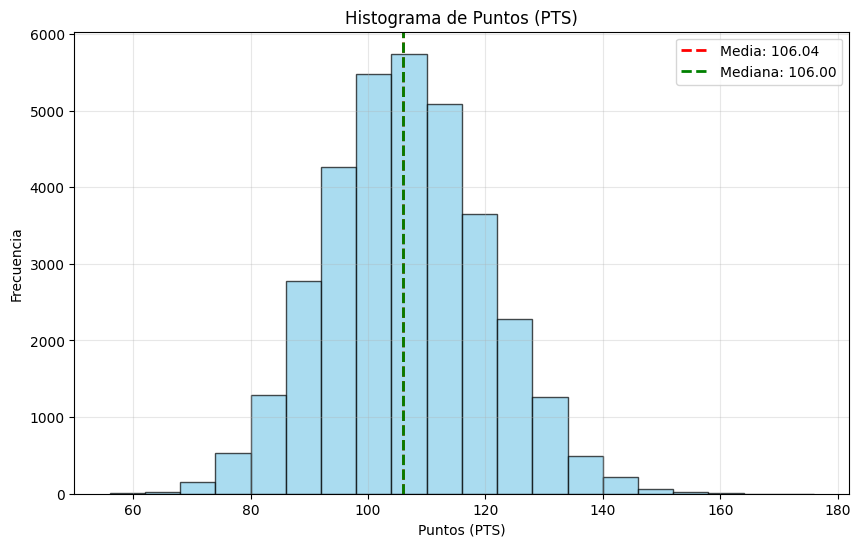

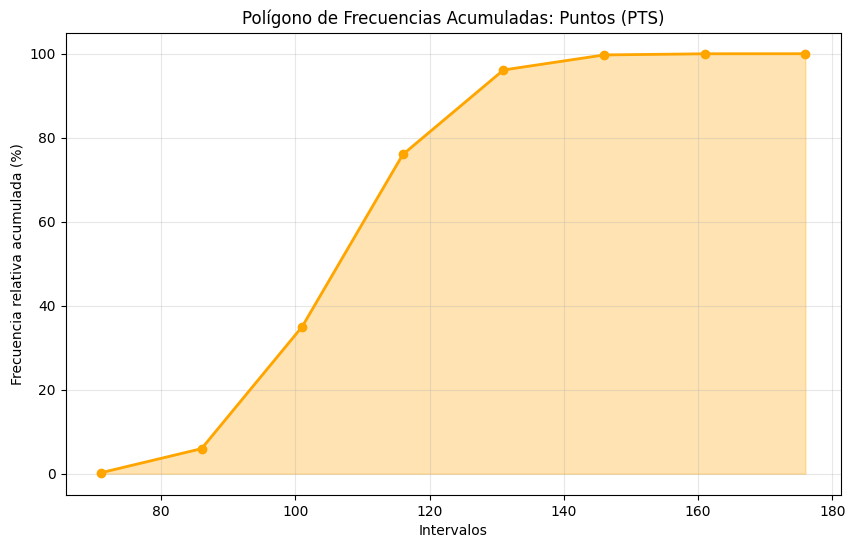

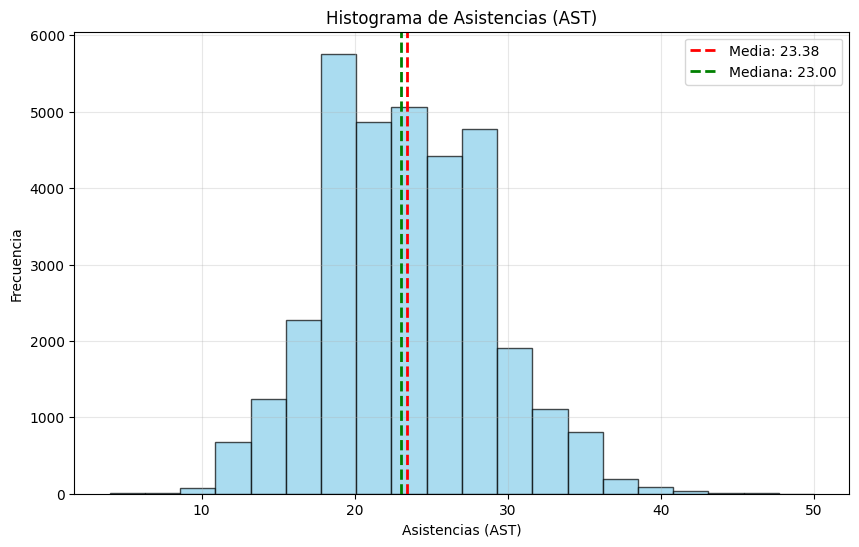

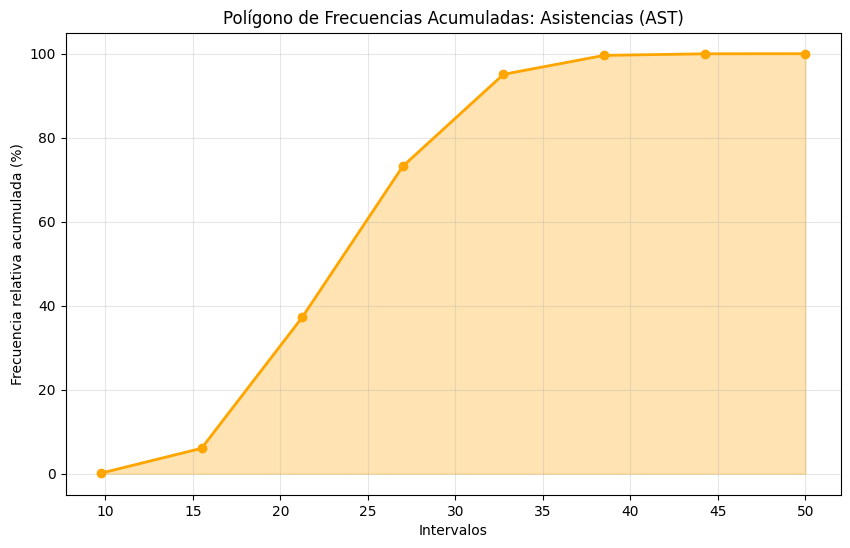

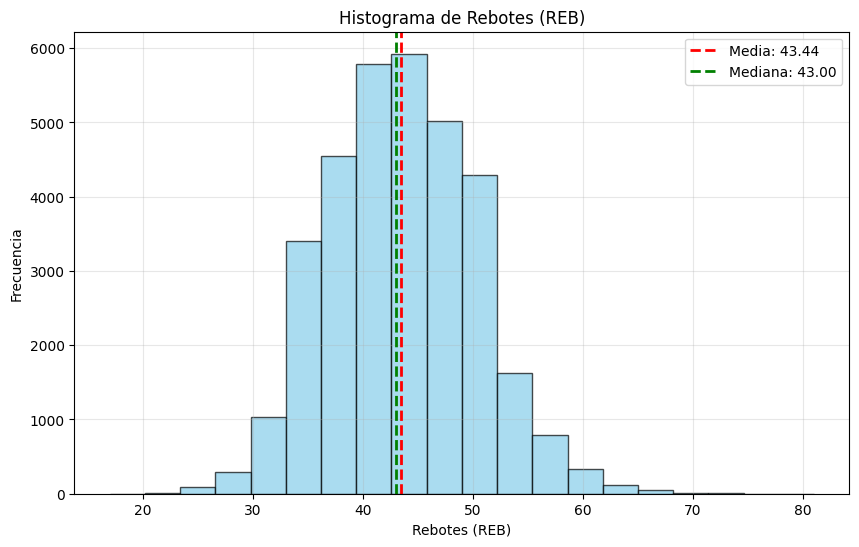

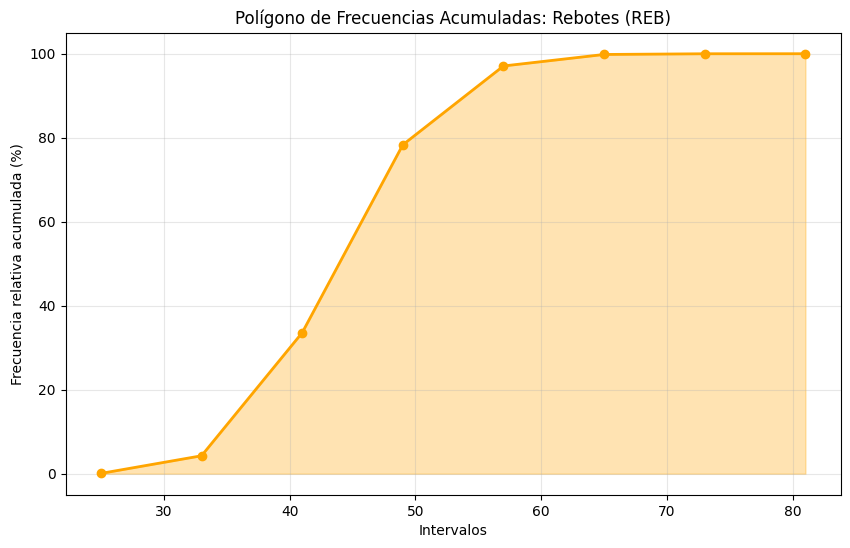

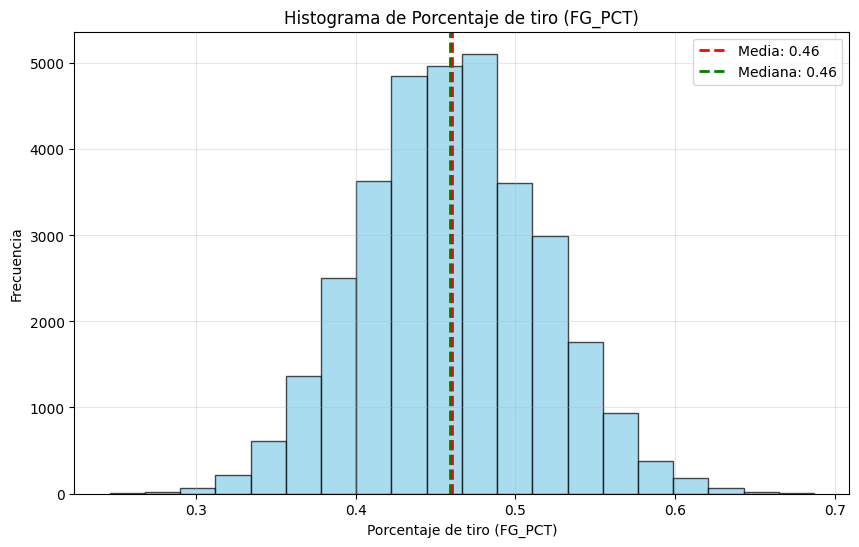

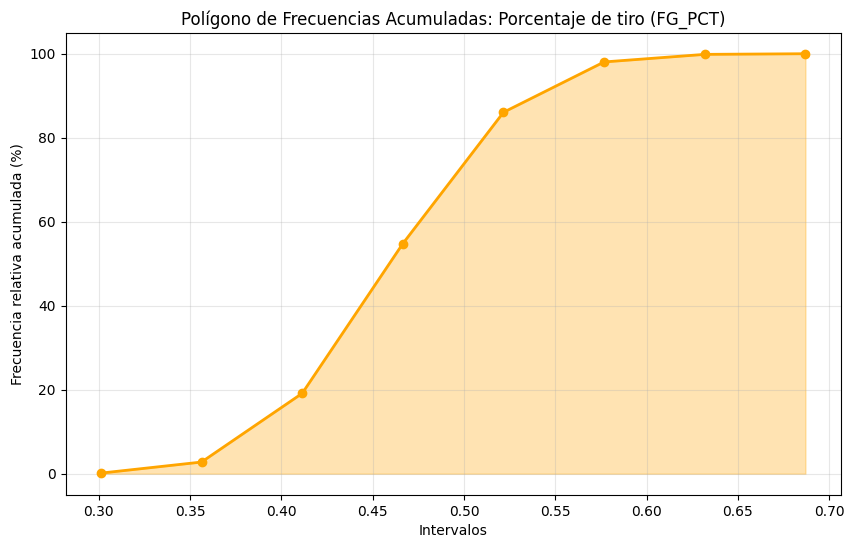

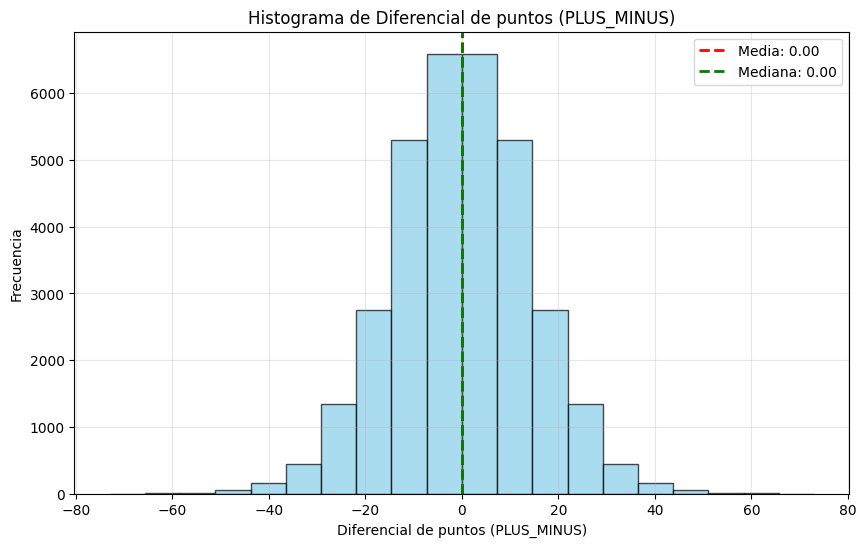

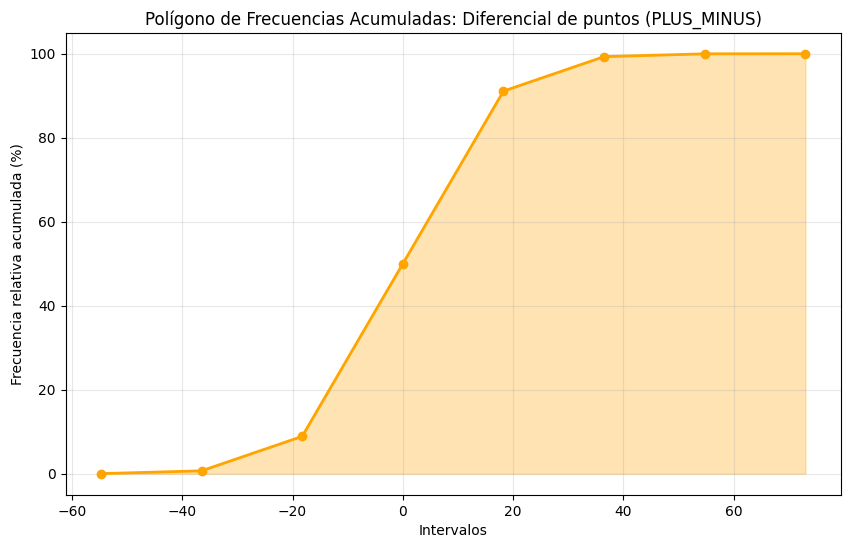

In [16]:
# ==========================================
# CELDA 2: HISTOGRAMAS Y POLÍGONOS ACUMULADOS
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
import os

SAVE_IMAGES = True
IMAGE_DIR = "images"

if SAVE_IMAGES:
    os.makedirs(IMAGE_DIR, exist_ok=True)

variables = {
    "PTS": "Puntos (PTS)",
    "AST": "Asistencias (AST)",
    "REB": "Rebotes (REB)",
    "FG_PCT": "Porcentaje de tiro (FG_PCT)",
    "PLUS_MINUS": "Diferencial de puntos (PLUS_MINUS)"
}

for var, label in variables.items():
    data = df[var].dropna()

    media = data.mean()
    mediana = data.median()

    # --------------------------------------
    # HISTOGRAMA
    # --------------------------------------
    plt.figure(figsize=(10, 6))
    plt.hist(
        data,
        bins=20,
        color="skyblue",
        edgecolor="black",
        alpha=0.7
    )

    plt.axvline(
        media,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Media: {media:.2f}"
    )
    plt.axvline(
        mediana,
        color="green",
        linestyle="--",
        linewidth=2,
        label=f"Mediana: {mediana:.2f}"
    )

    plt.xlabel(label)
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {label}")
    plt.legend()
    plt.grid(alpha=0.3)

    if SAVE_IMAGES:
        plt.savefig(
            f"{IMAGE_DIR}/histograma_{var.lower()}.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    # --------------------------------------
    # POLÍGONO DE FRECUENCIA ACUMULADA
    # --------------------------------------
    counts, bin_edges = np.histogram(data, bins=8)
    cumulative = np.cumsum(counts)
    cumulative_pct = cumulative / cumulative[-1] * 100

    plt.figure(figsize=(10, 6))
    plt.plot(
        bin_edges[1:],
        cumulative_pct,
        color="orange",
        marker="o",
        linewidth=2
    )
    plt.fill_between(
        bin_edges[1:],
        cumulative_pct,
        color="orange",
        alpha=0.3
    )

    plt.xlabel("Intervalos")
    plt.ylabel("Frecuencia relativa acumulada (%)")
    plt.title(f"Polígono de Frecuencias Acumuladas: {label}")
    plt.grid(alpha=0.3)

    if SAVE_IMAGES:
        plt.savefig(
            f"{IMAGE_DIR}/poligono_acumulado_{var.lower()}.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


Código para generar boxplots

C:\Users\marti\AppData\Local\Temp\ipykernel_5108\620260381.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


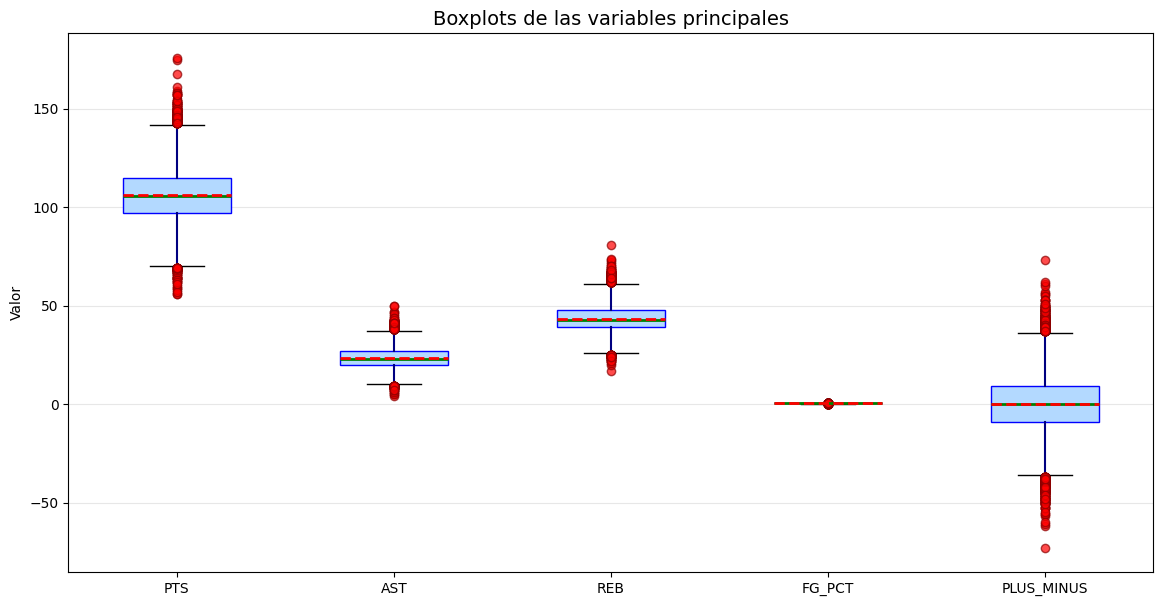

In [17]:
# ==========================================
# CELDA 3: BOXPLOTS Y OUTLIERS (ALTO CONTRASTE)
# ==========================================

data_box = [df[var].dropna() for var in variables.keys()]

plt.figure(figsize=(14, 7))

box = plt.boxplot(
    data_box,
    labels=variables.keys(),
    patch_artist=True,
    showmeans=True,
    meanline=True
)

# Colores de las cajas
for patch in box["boxes"]:
    patch.set_facecolor("#B3D9FF")  # azul claro
    patch.set_edgecolor("blue")

# Bigotes
for whisker in box["whiskers"]:
    whisker.set(color="navy", linewidth=1.5)

# Líneas de mediana
for median in box["medians"]:
    median.set(color="green", linewidth=2)

# Media
for mean in box["means"]:
    mean.set(color="red", linewidth=2)

# Outliers
for flier in box["fliers"]:
    flier.set(
        marker="o",
        markerfacecolor="red",
        markeredgecolor="darkred",
        alpha=0.7
    )

plt.title("Boxplots de las variables principales", fontsize=14)
plt.ylabel("Valor")
plt.grid(axis="y", alpha=0.3)

if SAVE_IMAGES:
    plt.savefig(
        f"{IMAGE_DIR}/boxplots.png",
        dpi=300,
        bbox_inches="tight"
    )

plt.show()


Código para ver gráficos de asimetría y curtosis

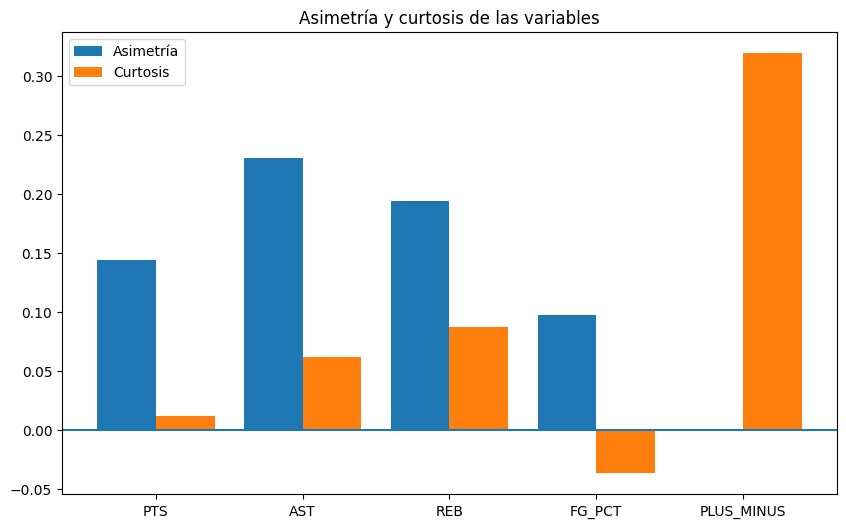

In [15]:
# ==========================================
# ASIMETRÍA Y CURTOSIS
# ==========================================

from scipy.stats import skew, kurtosis

skewness = []
kurt = []

for var in variables.keys():
    data = df[var].dropna()
    skewness.append(skew(data))
    kurt.append(kurtosis(data))  # exceso de curtosis

x = np.arange(len(variables))

plt.figure(figsize=(10, 6))
plt.bar(x - 0.2, skewness, width=0.4, label="Asimetría")
plt.bar(x + 0.2, kurt, width=0.4, label="Curtosis")

plt.xticks(x, variables.keys())
plt.axhline(0)
plt.legend()
plt.title("Asimetría y curtosis de las variables")

if SAVE_IMAGES:
    plt.savefig(f"{IMAGE_DIR}/asimetria_curtosis.png",
                dpi=300, bbox_inches="tight")

plt.show()


Código para generar la matriz de correlación y la tabla de outliers de las variables principales a analizar

In [18]:
# =====================================================
#  - Matriz de correlación
#  - Outliers (método IQR)
# =====================================================

import pandas as pd
import numpy as np
import os

# ----------------------
# CONFIGURACIÓN
# ----------------------
EXPORT_TEX = True          # True -> genera .tex | False -> solo muestra tablas
TEX_DIR = "latex_tables"

if EXPORT_TEX:
    os.makedirs(TEX_DIR, exist_ok=True)

# ----------------------
# VARIABLES ANALIZADAS
# ----------------------
variables = ["PTS", "REB", "AST", "FG_PCT", "PLUS_MINUS"]

# =====================================================
# 1) MATRIZ DE CORRELACIÓN
# =====================================================
corr_matrix = df[variables].corr().round(4)

print("Matriz de correlación:")
display(corr_matrix)

if EXPORT_TEX:
    corr_latex = corr_matrix.to_latex(
        caption="Matriz de correlación entre variables principales",
        label="tab:correlacion",
        column_format="l" + "c" * len(variables),
        bold_rows=True
    )

    with open(f"{TEX_DIR}/matriz_correlacion.tex", "w", encoding="utf-8") as f:
        f.write(corr_latex)

# =====================================================
# 2) OUTLIERS — MÉTODO IQR
# =====================================================
def outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return len(series), len(outliers), round(len(outliers)/len(series)*100, 2), round(lower,2), round(upper,2)

outlier_data = []

for var in ["PTS", "REB", "AST", "PLUS_MINUS"]:
    total, n_out, pct, low, up = outliers_iqr(df[var].dropna())
    outlier_data.append([var, total, n_out, pct, low, up])

outliers_df = pd.DataFrame(
    outlier_data,
    columns=["Variable", "Total", "Outliers", "%", "Límite Inf.", "Límite Sup."]
)

print("Tabla de outliers (IQR):")
display(outliers_df)

if EXPORT_TEX:
    outliers_latex = outliers_df.to_latex(
        index=False,
        caption="Detección de outliers usando el método IQR",
        label="tab:outliers_iqr",
        column_format="lccccc"
    )

    with open(f"{TEX_DIR}/tabla_outliers.tex", "w", encoding="utf-8") as f:
        f.write(outliers_latex)


Matriz de correlación:


,PTS,REB,AST,FG_PCT,PLUS_MINUS
PTS,1.0000,0.1497,0.6186,0.6855,0.5215
REB,0.1497,1.0000,0.0516,-0.1707,0.3402
AST,0.6186,0.0516,1.0000,0.5591,0.3962
FG_PCT,0.6855,-0.1707,0.5591,1.0000,0.5469
PLUS_MINUS,0.5215,0.3402,0.3962,0.5469,1.0000


Tabla de outliers (IQR):


,Variable,Total,Outliers,%,Límite Inf.,Límite Sup.
0,PTS,33316,231,0.69,70.0,142.0
1,REB,33316,229,0.69,25.5,61.5
2,AST,33316,260,0.78,9.5,37.5
3,PLUS_MINUS,33316,460,1.38,-36.0,36.0


Iniciando con la preparacion del Dataset para hacer las pruebas necesarias, inicialmente se va a analizar el dataset para ver si hay datos faltantes

In [23]:
# ==========================================
# ANÁLISIS DE VALORES FALTANTES (SECCIÓN 3.3)
# ==========================================

import os

# --------------------------------------------------
# CONFIGURACIÓN
# --------------------------------------------------
EXPORT_TEX = True                  # True -> genera .tex | False -> solo muestra tabla
TEX_DIR = "latex_tables"
TEX_FILENAME = "valores_faltantes.tex"

if EXPORT_TEX:
    os.makedirs(TEX_DIR, exist_ok=True)

# --------------------------------------------------
# VARIABLES ANALIZADAS
# --------------------------------------------------
variables_prep = ["PTS", "REB", "AST", "FG_PCT", "PLUS_MINUS"]

# --------------------------------------------------
# CÁLCULO DE VALORES FALTANTES
# --------------------------------------------------
total_obs = len(df)
na_info = []

for var in variables_prep:
    n_na = df[var].isna().sum()
    pct_na = round(n_na / total_obs * 100, 3)

    tratamiento = (
        "Imputación por mediana" if n_na > 0 else "No requiere tratamiento"
    )

    na_info.append([var, n_na, pct_na, tratamiento])

tabla_na = pd.DataFrame(
    na_info,
    columns=[
        "Variable",
        "Valores Faltantes",
        "Porcentaje (%)",
        "Tratamiento Aplicado"
    ]
)

# --------------------------------------------------
# MOSTRAR TABLA
# --------------------------------------------------
print("Tabla de valores faltantes:")
display(tabla_na)

# --------------------------------------------------
# EXPORTACIÓN A LaTeX (OPCIONAL)
# --------------------------------------------------
if EXPORT_TEX:
    latex_table = tabla_na.to_latex(
        index=False,
        caption="Tratamiento de valores faltantes en las variables analizadas",
        label="tab:valores_faltantes",
        column_format="lccc"
    )

    tex_path = os.path.join(TEX_DIR, TEX_FILENAME)

    with open(tex_path, "w", encoding="utf-8") as f:
        f.write(latex_table)

    print(f"✔ Archivo LaTeX generado: {tex_path}")


Tabla de valores faltantes:


,Variable,Valores Faltantes,Porcentaje (%),Tratamiento Aplicado
0,PTS,0,0.0,No requiere tratamiento
1,REB,0,0.0,No requiere tratamiento
2,AST,0,0.0,No requiere tratamiento
3,FG_PCT,0,0.0,No requiere tratamiento
4,PLUS_MINUS,0,0.0,No requiere tratamiento


✔ Archivo LaTeX generado: latex_tables\valores_faltantes.tex


Creación de variables derivadas de las variables iniciales del dataset para poder obtener más información a analizar

In [28]:
# ===============================
# 📌 Creación de Variables Derivadas Avanzadas
# ===============================

# 1️⃣ Posesiones estimadas (POSS)
# Fórmula NBA estándar: FGA - OREB + TOV + 0.4*FTA
# Representa la cantidad de posesiones que tiene un equipo por partido
df_out['POSS'] = df_out['FGA'] - df_out['OREB'] + df_out['TOV'] + 0.4 * df_out['FTA']

# 2️⃣ Ritmo de juego (PACE)
# Se calcula como el número de posesiones por 48 minutos, para estandarizar el ritmo de juego
df_out['PACE'] = (df_out['POSS'] / df_out['MIN']) * 48

# 3️⃣ Eficiencia ofensiva (OFF_EFF)
# Puntos anotados por cada 100 posesiones
# Métrica clave para comparar la eficiencia ofensiva entre equipos
df_out['OFF_EFF'] = (df_out['PTS'] / df_out['POSS']) * 100

# 4️⃣ Ratio Asistencias/Pérdidas (AST_TO_RATIO)
# Relaciona la creatividad ofensiva (AST) con el cuidado del balón (TOV)
# Valores mayores indican mejor gestión del balón
df_out['AST_TO_RATIO'] = df_out['AST'] / df_out['TOV']

# 5️⃣ Tasa de triples intentados (FG3A_RATE)
# Porcentaje de tiros de tres puntos respecto al total de tiros de campo
# Indica la "dependencia" de un equipo en los triples
df_out['FG3A_RATE'] = df_out['FG3A'] / df_out['FGA']

# 6️⃣ Puntuación eficiente (EFFICIENT_SCORING)
# Métrica ponderada que valora más los triples: FG_PCT + 0.5*FG3_PCT
# Captura la eficiencia real de anotación considerando el mayor valor de los triples
df_out['EFFICIENT_SCORING'] = df_out['FG_PCT'] + 0.5 * df_out['FG3_PCT']

# -------------------------------
# Vista rápida de las variables derivadas
# -------------------------------
print("✅ Primeros 5 registros de variables derivadas:")
print(df_out[['POSS','PACE','OFF_EFF','AST_TO_RATIO','FG3A_RATE','EFFICIENT_SCORING']].head())


✅ Primeros 5 registros de variables derivadas:
        POSS       PACE   OFF_EFF  AST_TO_RATIO  FG3A_RATE  EFFICIENT_SCORING
0  93.860461  93.860461  3.996161      9.738064   0.510417           1.138989
1  88.716563  88.716563  3.149337      2.283048   0.554348           1.036299
2  86.140969  86.140969  2.047283      1.266857   0.448718           1.165818
3  87.228766  87.228766  2.781159      2.722065   0.397849           1.047043
4  95.067751  95.067751  3.326044     -1.512997   0.570000           0.925464


El siguiente código hace toda la preparacion de los datos para su posterior procesamiento,
Calcula Z-score y Min-Max de las variables que usas en tus modelos y deja el dataset listo para Pregunta 1–3, y codifica de manera categórica wl
Aplica Winsorizing a PLUS_MINUS
Crea nuevas variables mas complejas que se van a utilizar en los análisis

In [ ]:
# ===============================
# 📌 Preprocesamiento Completo NBA 2010-2024
# ===============================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# -------------------------------------------------
# 1️⃣ Cargar datos
# -------------------------------------------------
# Descomenta si aún no has cargado el dataframe
# df = pd.read_csv("nba_2010_2024.csv")  

# Crear copia de trabajo para no alterar el original
df_prep = df.copy()

# -------------------------------------------------
# 2️⃣ Codificación binaria de la variable objetivo
# -------------------------------------------------
# 'W' -> 1, 'L' -> 0 para modelos de clasificación
df_prep["WL_bin"] = df_prep["WL"].map({"W": 1, "L": 0})

# -------------------------------------------------
# 3️⃣ Variables numéricas para Z-score y Min-Max
# -------------------------------------------------
vars_zscore = ['PTS', 'AST', 'REB', 'STL', 'BLK', 'TOV']   # Variables a estandarizar
vars_minmax = ['FG_PCT', 'FG3_PCT', 'FT_PCT']             # Variables a normalizar

# -------------------------------
# 3a️⃣ Estandarización Z-score
# -------------------------------
scaler_z = StandardScaler()
df_prep[vars_zscore] = scaler_z.fit_transform(df_prep[vars_zscore])

# -------------------------------
# 3b️⃣ Normalización Min-Max
# -------------------------------
scaler_mm = MinMaxScaler()
df_prep[vars_minmax] = scaler_mm.fit_transform(df_prep[vars_minmax])

# -------------------------------------------------
# 4️⃣ Tratamiento de outliers (Winsorizing)
# -------------------------------------------------
# Solo para PLUS_MINUS, los otros se mantienen
q05 = df_prep['PLUS_MINUS'].quantile(0.05)
q95 = df_prep['PLUS_MINUS'].quantile(0.95)
df_prep['PLUS_MINUS_W'] = df_prep['PLUS_MINUS'].clip(lower=q05, upper=q95)

# -------------------------------------------------
# 5️⃣ Creación de Variables Derivadas Avanzadas
# -------------------------------------------------
# Capturan métricas de rendimiento avanzado
# 1️⃣ Posesiones estimadas (POSS)
# Fórmula NBA estándar: FGA - OREB + TOV + 0.4*FTA
# Representa la cantidad de posesiones que tiene un equipo por partido
df_prep['POSS'] = df_prep['FGA'] - df_prep['OREB'] + df_prep['TOV'] + 0.4 * df_prep['FTA']

# 2️⃣ Ritmo de juego (PACE)
# Se calcula como el número de posesiones por 48 minutos, para estandarizar el ritmo de juego
df_prep['PACE'] = (df_prep['POSS'] / df_prep['MIN']) * 48

# 3️⃣ Eficiencia ofensiva (OFF_EFF)
# Puntos anotados por cada 100 posesiones
# Métrica clave para comparar la eficiencia ofensiva entre equipos
df_prep['OFF_EFF'] = (df_prep['PTS'] / df_prep['POSS']) * 100

# 4️⃣ Ratio Asistencias/Pérdidas (AST_TO_RATIO)
# Relaciona la creatividad ofensiva (AST) con el cuidado del balón (TOV)
# Valores mayores indican mejor gestión del balón
df_prep['AST_TO_RATIO'] = df_prep['AST'] / df_prep['TOV']

# 5️⃣ Tasa de triples intentados (FG3A_RATE)
# Porcentaje de tiros de tres puntos respecto al total de tiros de campo
# Indica la "dependencia" de un equipo en los triples
df_prep['FG3A_RATE'] = df_prep['FG3A'] / df_prep['FGA']

# 6️⃣ Puntuación eficiente (EFFICIENT_SCORING)
# Métrica ponderada que valora más los triples: FG_PCT + 0.5*FG3_PCT
# Captura la eficiencia real de anotación considerando el mayor valor de los triples
df_prep['EFFICIENT_SCORING'] = df_prep['FG_PCT'] + 0.5 * df_prep['FG3_PCT']

# -------------------------------------------------
# 6️⃣ Vista rápida de variables procesadas
# -------------------------------------------------
print("✅ Primeros 5 registros de variables Z-score:\n", df_prep[vars_zscore].head())
print("\n✅ Primeros 5 registros de variables Min-Max:\n", df_prep[vars_minmax].head())
print("\n✅ Variable objetivo codificada (WL_bin):\n", df_prep[['WL', 'WL_bin']].head())
print("\n✅ PLUS_MINUS Winsorizado:\n", df_prep[['PLUS_MINUS', 'PLUS_MINUS_W']].head())
print("\n✅ Primeros 5 registros de variables derivadas:\n", 
      df_prep[['POSS','PACE','OFF_EFF','AST_TO_RATIO','FG3A_RATE','EFFICIENT_SCORING']].head())

# -------------------------------------------------
# 7️⃣ Estadísticos descriptivos rápidos
# -------------------------------------------------
estad_desc = df_prep[['PTS','REB','AST','FG_PCT','PLUS_MINUS']].describe().T
estad_desc['Coef_Var'] = estad_desc['std'] / estad_desc['mean'] * 100  # Coeficiente de variación %
print("\n✅ Estadísticos descriptivos principales:\n", estad_desc)

# -------------------------------------------------
# 8️⃣ Opcional: guardar dataframe final preprocesado
# -------------------------------------------------
# df_prep.to_csv("nba_2010_2024_preprocesado_completo.csv", index=False)


✅ Primeros 5 registros de variables Z-score:
         PTS       AST       REB       STL       BLK       TOV
0  3.750815  4.484003  2.205704  1.854353  0.442132  0.460461
1  2.793983  1.635948  0.235802  2.199263 -1.135555  0.716563
2  1.763549  2.205559 -0.218791  0.819622 -1.135555  1.740969
3  2.425971  3.344781  0.387333  0.474712  1.230975  1.228766
4  3.161995  2.015688  1.296519  1.509442  0.047710 -1.332249

✅ Primeros 5 registros de variables Min-Max:
      FG_PCT   FG3_PCT  FT_PCT
0  0.811791  0.654394   0.875
1  0.698413  0.675772   0.867
2  0.809524  0.712589   0.577
3  0.709751  0.674584   0.700
4  0.643991  0.562945   0.762

✅ Variable objetivo codificada (WL_bin):
   WL  WL_bin
0  W       1
1  W       1
2  W       1
3  W       1
4  W       1

✅ PLUS_MINUS Winsorizado:
    PLUS_MINUS  PLUS_MINUS_W
0        56.0          23.0
1        47.0          23.0
2        36.0          23.0
3        34.0          23.0
4        36.0          23.0

✅ Primeros 5 registros de variables d

ejecutando pruebas de regresión logística para responder a la pregunta 1

Optimization terminated successfully.
         Current function value: 0.576483
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              WL_BINARY   No. Observations:                33316
Model:                          Logit   Df Residuals:                    33313
Method:                           MLE   Df Model:                            2
Date:                Tue, 20 Jan 2026   Pseudo R-squ.:                  0.1683
Time:                        02:11:47   Log-Likelihood:                -19206.
converged:                       True   LL-Null:                       -23093.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.6357      0.063    -73.259      0.000      -4.760      -4.512
FG3M           0.0496      0.

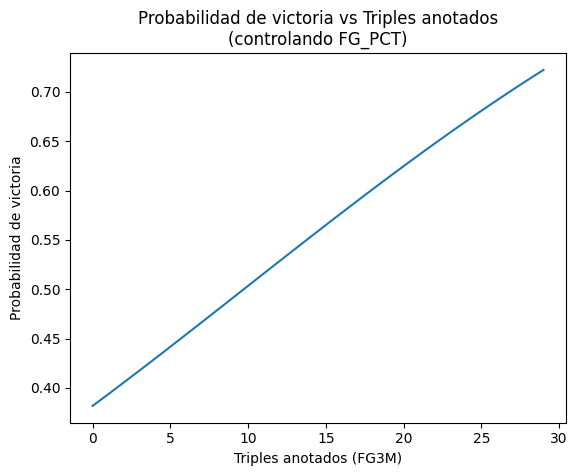

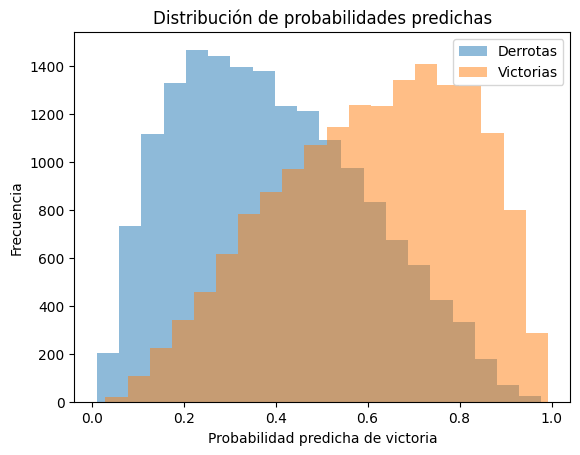


Conclusión:
Existe una relación estadísticamente significativa entre FG3M y la victoria,
controlando por la efectividad general de tiro (FG_PCT).


In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# =========================
# 1. Cargar datos
# =========================
df = pd.read_csv("nba_2010_2024_preprocesado_completo.csv")

# =========================
# 2. Preparar variables
# =========================
data = df[['FG3M', 'FG_PCT', 'WL']].copy()
data['WL_BINARY'] = data['WL'].map({'W': 1, 'L': 0})
data = data.dropna()

X = data[['FG3M', 'FG_PCT']]
y = data['WL_BINARY']

# Agregar intercepto
X_const = sm.add_constant(X)

# =========================
# 3. Regresión logística binaria
# =========================
model = sm.Logit(y, X_const)
result = model.fit()

print(result.summary())

# Odds Ratios
print("\nOdds Ratios:")
print(np.exp(result.params))

# =========================
# 4. Gráfico 1: Probabilidad vs FG3M
# =========================
fg3m_range = np.linspace(X['FG3M'].min(), X['FG3M'].max(), 100)
fg_pct_mean = X['FG_PCT'].mean()

X_pred = pd.DataFrame({
    'const': 1,
    'FG3M': fg3m_range,
    'FG_PCT': fg_pct_mean
})

prob_win = result.predict(X_pred)

plt.figure()
plt.plot(fg3m_range, prob_win)
plt.xlabel("Triples anotados (FG3M)")
plt.ylabel("Probabilidad de victoria")
plt.title("Probabilidad de victoria vs Triples anotados\n(controlando FG_PCT)")
plt.show()

# =========================
# 5. Gráfico 2: Distribución de probabilidades
# =========================
data['prob_predicha'] = result.predict(X_const)

plt.figure()
plt.hist(data.loc[data['WL_BINARY'] == 0, 'prob_predicha'],
         bins=20, alpha=0.5, label='Derrotas')
plt.hist(data.loc[data['WL_BINARY'] == 1, 'prob_predicha'],
         bins=20, alpha=0.5, label='Victorias')
plt.xlabel("Probabilidad predicha de victoria")
plt.ylabel("Frecuencia")
plt.title("Distribución de probabilidades predichas")
plt.legend()
plt.show()

# =========================
# 6. Conclusión automática
# =========================
p_fg3m = result.pvalues['FG3M']

print("\nConclusión:")
if p_fg3m < 0.05:
    print("Existe una relación estadísticamente significativa entre FG3M y la victoria,")
    print("controlando por la efectividad general de tiro (FG_PCT).")
else:
    print("No se encuentra una relación estadísticamente significativa entre FG3M y la victoria.")


A continuación se ejecutan las pruebas de regresión lineal simple y de anova para responder a la pregunta 2

In [2]:
# ===========================================
# PREGUNTA 2: REGRESIÓN LINEAL SIMPLE
# ===========================================
# Objetivo: Cuantificar la tendencia temporal de PTS y FG3A/FGA
# Usando exclusivamente datos reales del dataset NBA

import pandas as pd
from scipy import stats
import os

# -------------------------------------------
# Cargar dataset real
# -------------------------------------------
FILE_NAME = 'nba_2010_2024_preprocesado_completo.csv'

if not os.path.exists(FILE_NAME):
    raise FileNotFoundError(f"No se encontró el archivo: {FILE_NAME}")

df = pd.read_csv(FILE_NAME)

# -------------------------------------------
# Comprobación de columnas necesarias
# -------------------------------------------
columnas_necesarias = ['SEASON_YEAR', 'PTS', 'FG3A', 'FGA']

faltantes = [c for c in columnas_necesarias if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltan columnas necesarias en el CSV: {faltantes}")

# -------------------------------------------
# Preparación de variables
# -------------------------------------------
# Convertir temporada a valor numérico (año inicial)
df['SEASON_NUM'] = df['SEASON_YEAR'].str[:4].astype(int)

# Proporción de triples intentados
df['FG3A_RATIO'] = df['FG3A'] / df['FGA']

# Agrupar por temporada (medias)
medias = (
    df.groupby('SEASON_NUM')
      .agg({
          'PTS': 'mean',
          'FG3A_RATIO': 'mean'
      })
      .reset_index()
)

X = medias['SEASON_NUM'].values
y_pts = medias['PTS'].values
y_fg3 = medias['FG3A_RATIO'].values

# ==========================================
# REGRESIÓN: PUNTOS POR PARTIDO
# ==========================================
slope_pts, intercept_pts, r_pts, p_pts, se_pts = stats.linregress(X, y_pts)
r2_pts = r_pts ** 2

print("=" * 60)
print("REGRESIÓN LINEAL: PTS ~ SEASON")
print("=" * 60)
print(f"Ecuación: PTS = {slope_pts:.3f} × AÑO + {intercept_pts:.2f}")
print(f"Pendiente (β₁): {slope_pts:.3f} puntos/temporada")
print(f"R²: {r2_pts:.4f} ({r2_pts*100:.1f}% varianza explicada)")
print(f"Valor p: {p_pts:.2e}")

# ==========================================
# REGRESIÓN: PROPORCIÓN DE TRIPLES
# ==========================================
slope_fg3, intercept_fg3, r_fg3, p_fg3, se_fg3 = stats.linregress(X, y_fg3)
r2_fg3 = r_fg3 ** 2

print("\n" + "=" * 60)
print("REGRESIÓN LINEAL: FG3A/FGA ~ SEASON")
print("=" * 60)
print(f"Ecuación: FG3A/FGA = {slope_fg3:.5f} × AÑO + {intercept_fg3:.4f}")
print(f"Pendiente (β₁): {slope_fg3*100:.2f}% por temporada")
print(f"R²: {r2_fg3:.4f} ({r2_fg3*100:.1f}% varianza explicada)")
print(f"Valor p: {p_fg3:.2e}")


REGRESIÓN LINEAL: PTS ~ SEASON
Ecuación: PTS = 0.108 × AÑO + -218.04
Pendiente (β₁): 0.108 puntos/temporada
R²: 0.9222 (92.2% varianza explicada)
Valor p: 5.17e-08

REGRESIÓN LINEAL: FG3A/FGA ~ SEASON
Ecuación: FG3A/FGA = 0.01580 × AÑO + -31.5471
Pendiente (β₁): 1.58% por temporada
R²: 0.9520 (95.2% varianza explicada)
Valor p: 2.80e-09


In [3]:
# ===========================================
# PREGUNTA 2: ANOVA POR TEMPORADA
# ===========================================
# Objetivo: Verificar si las diferencias de PTS y proporción de triples
# entre temporadas son estadísticamente significativas
# Usando exclusivamente datos reales del dataset NBA

import pandas as pd
from scipy import stats
import os

# -------------------------------------------
# Cargar dataset real
# -------------------------------------------
FILE_NAME = 'nba_2010_2024_preprocesado_completo.csv'

if not os.path.exists(FILE_NAME):
    raise FileNotFoundError(f"No se encontró el archivo: {FILE_NAME}")

df = pd.read_csv(FILE_NAME)

# -------------------------------------------
# Comprobación de columnas necesarias
# -------------------------------------------
columnas_necesarias = ['SEASON_YEAR', 'PTS', 'FG3A', 'FGA']
faltantes = [c for c in columnas_necesarias if c not in df.columns]

if faltantes:
    raise ValueError(f"Faltan columnas necesarias en el CSV: {faltantes}")

# -------------------------------------------
# Variables derivadas
# -------------------------------------------
df['FG3A_RATIO'] = df['FG3A'] / df['FGA']

# -------------------------------------------
# Medias descriptivas por temporada
# -------------------------------------------
temporadas = (
    df.groupby('SEASON_YEAR')
      .agg({
          'PTS': 'mean',
          'FG3A_RATIO': 'mean'
      })
      .reset_index()
)

print("=" * 60)
print("MEDIAS POR TEMPORADA")
print("=" * 60)
print(temporadas.to_string(index=False))

# ==========================================
# ANOVA: Puntos por Partido (PTS)
# ==========================================
grupos_pts = [
    grupo['PTS'].dropna().values
    for _, grupo in df.groupby('SEASON_YEAR')
]

f_pts, p_pts = stats.f_oneway(*grupos_pts)

print("\n" + "=" * 60)
print("ANOVA: PUNTOS POR PARTIDO (PTS)")
print("=" * 60)
print(f"Estadístico F: {f_pts:.4f}")
print(f"Valor p: {p_pts:.2e}")
print(f"Significativo (α=0.05): {'Sí' if p_pts < 0.05 else 'No'}")

# ==========================================
# ANOVA: Proporción de Triples (FG3A/FGA)
# ==========================================
grupos_fg3 = [
    grupo['FG3A_RATIO'].dropna().values
    for _, grupo in df.groupby('SEASON_YEAR')
]

f_fg3, p_fg3 = stats.f_oneway(*grupos_fg3)

print("\n" + "=" * 60)
print("ANOVA: PROPORCIÓN DE TRIPLES (FG3A/FGA)")
print("=" * 60)
print(f"Estadístico F: {f_fg3:.4f}")
print(f"Valor p: {p_fg3:.2e}")
print(f"Significativo (α=0.05): {'Sí' if p_fg3 < 0.05 else 'No'}")


MEDIAS POR TEMPORADA
SEASON_YEAR       PTS  FG3A_RATIO
    2010-11 -0.477615    0.222135
    2011-12 -0.719827    0.226304
    2012-13 -0.581578    0.243928
    2013-14 -0.370264    0.260029
    2014-15 -0.443477    0.268483
    2015-16 -0.247892    0.285100
    2016-17 -0.033039    0.316778
    2017-18  0.021625    0.337869
    2018-19  0.380451    0.359177
    2019-20  0.423832    0.384487
    2020-21  0.445418    0.392786
    2021-22  0.336829    0.400175
    2022-23  0.636385    0.388301
    2023-24  0.601468    0.395183

ANOVA: PUNTOS POR PARTIDO (PTS)
Estadístico F: 647.8556
Valor p: 0.00e+00
Significativo (α=0.05): Sí

ANOVA: PROPORCIÓN DE TRIPLES (FG3A/FGA)
Estadístico F: 1950.5527
Valor p: 0.00e+00
Significativo (α=0.05): Sí


El código siguiente responde a la prueba de regresión múltiple para responder a la pregunta 3

In [4]:
# ===========================================
# PREGUNTA 3: REGRESIÓN MÚLTIPLE
# ===========================================
# Genera: generated/pregunta3.tex

import pandas as pd
import numpy as np
from scipy import stats
import os

FILE_NAME = 'nba_2010_2024_preprocesado_completo.csv'

df = pd.read_csv(FILE_NAME)
  
# Predictores y variable dependiente
predictores = ['AST', 'REB', 'STL', 'TOV', 'FG_PCT']
X = df[predictores].dropna()
y = df.loc[X.index, 'PLUS_MINUS']

# Matriz de diseño con intercepto
X_mat = np.column_stack([np.ones(len(X)), X.values])

# Coeficientes usando pseudo-inversa para robustez
XtX_inv = np.linalg.pinv(X_mat.T @ X_mat)
beta = XtX_inv @ X_mat.T @ y.values

# Predicciones y residuos
y_pred = X_mat @ beta
residuos = y.values - y_pred
n_obs, k = len(y), len(predictores)

# Estadísticas R²
ss_res = np.sum(residuos**2)
ss_tot = np.sum((y.values - y.mean())**2)
r2 = 1 - ss_res/ss_tot
r2_adj = 1 - (1-r2)*(n_obs-1)/(n_obs-k-1)

# Error estándar de los coeficientes
mse = ss_res / (n_obs - k - 1)
se_beta = np.sqrt(np.diag(XtX_inv) * mse)

# Estadísticos t y p-values
t_stats = beta / se_beta
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), n_obs - k - 1))

# Estadístico F global
f_stat = (r2 / k) / ((1 - r2) / (n_obs - k - 1))

# Mostrar resultados
print("\n===== Resultados de la Regresión Múltiple =====")
print(f"R² = {r2:.4f}")
print(f"R² ajustado = {r2_adj:.4f}")
print(f"F-statistic = {f_stat:.3f} (gl_modelo={k}, gl_residuo={n_obs-k-1})\n")

print("Coeficientes:")
print(f"{'Variable':<10} {'Beta':>8} {'SE':>8} {'t':>8} {'p-value':>10}")
print("-"*50)
print(f"{'Intercept':<10} {beta[0]:>8.3f} {se_beta[0]:>8.3f} {t_stats[0]:>8.2f} {p_values[0]:>10.3g}")
for i, var in enumerate(predictores):
    print(f"{var:<10} {beta[i+1]:>8.3f} {se_beta[i+1]:>8.3f} {t_stats[i+1]:>8.2f} {p_values[i+1]:>10.3g}")



===== Resultados de la Regresión Múltiple =====
R² = 0.5852
R² ajustado = 0.5852
F-statistic = 9400.220 (gl_modelo=5, gl_residuo=33310)

Coeficientes:
Variable       Beta       SE        t    p-value
--------------------------------------------------
Intercept   -35.683    0.247  -144.34          0
AST          -0.371    0.062    -5.97   2.46e-09
REB           7.180    0.053   136.15          0
STL           3.384    0.051    66.38          0
TOV          -3.184    0.051   -62.17          0
FG_PCT       73.388    0.498   147.39          0
